In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
orders = pd.read_csv("../Datasets/archive/olist_orders_dataset.csv")
customers = pd.read_csv("../Datasets/archive/olist_customers_dataset.csv")
order_items = pd.read_csv("../Datasets/archive/olist_order_items_dataset.csv")
products = pd.read_csv("../Datasets/archive/olist_products_dataset.csv")
payments = pd.read_csv("../Datasets/archive/olist_order_payments_dataset.csv")
reviews = pd.read_csv("../Datasets/archive/olist_order_reviews_dataset.csv")

In [ ]:
sales_df = orders[['order_id','order_status','order_purchase_timestamp']]

In [5]:
sales_df.head()

,order_id,order_status,order_purchase_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,2018-07-24 20:41:37
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,2018-08-08 08:38:49
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,2017-11-18 19:28:06
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,2018-02-13 21:18:39


In [6]:
order_items.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')

In [7]:
sales_df = sales_df.merge(order_items[['order_id','product_id','price','freight_value']],on='order_id',how='left')

In [8]:
sales_df.columns

Index(['order_id', 'order_status', 'order_purchase_timestamp', 'product_id',
       'price', 'freight_value'],
      dtype='object')

In [9]:
products.columns

Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='object')

In [10]:
sales_df = sales_df.merge(products[['product_id','product_category_name']],on='product_id')

In [11]:
sales_df.head()

,order_id,order_status,order_purchase_timestamp,product_id,price,freight_value,product_category_name
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33,87285b34884572647811a353c7ac498a,29.99,8.72,utilidades_domesticas
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,2018-07-24 20:41:37,595fac2a385ac33a80bd5114aec74eb8,118.70,22.76,perfumaria
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,2018-08-08 08:38:49,aa4383b373c6aca5d8797843e5594415,159.90,19.22,automotivo
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,2017-11-18 19:28:06,d0b61bfb1de832b15ba9d266ca96e5b0,45.00,27.20,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,2018-02-13 21:18:39,65266b2da20d04dbe00c5c2d3bb7859e,19.90,8.72,papelaria


In [12]:
sales_df.shape

(112650, 7)

In [13]:
sales_df.isna().sum()

order_id                       0
order_status                   0
order_purchase_timestamp       0
product_id                     0
price                          0
freight_value                  0
product_category_name       1603
dtype: int64

In [14]:
sales_df['product_category_name'] = sales_df['product_category_name'].fillna("Unknown")

In [15]:
sales_df.isna().sum()

order_id                    0
order_status                0
order_purchase_timestamp    0
product_id                  0
price                       0
freight_value               0
product_category_name       0
dtype: int64

In [16]:
sales_df['order_purchase_timestamp'] = pd.to_datetime(sales_df['order_purchase_timestamp'])

In [17]:
sales_df['product_revenue'] = sales_df['price'] + sales_df['freight_value']

## KPIs - Total revenue, Total Orders, Total units sold, Total Freight, Average Order Value(AOV)

In [18]:
total_revenue = sales_df['product_revenue'].sum()
total_revenue

np.float64(15843553.239999998)

In [19]:
total_orders = sales_df['order_id'].nunique() 
total_orders

98666

In [20]:
sales_df['product_id'].count()

np.int64(112650)

In [21]:
total_freight = sales_df['freight_value'].sum() 
total_freight

np.float64(2251909.54)

In [22]:
AOV = total_revenue / total_orders
AOV

np.float64(160.57763809214924)

### Insigths :- 
    ## TOTAL REVENUE - 15843553.23 (15.8M)
    ## TOTAL FREIGHT - 2251909.54 (2.25M)
    ## UNIQUE ORDERS - 98666
    ## TOTAL ITEMS / PRODUCTS - 112650
    ## AVERAGE ORDER VALUE (AOV) - 160.58

## Business Growth (2017 vs 2018)

In [23]:
sales_df['order_month'] = sales_df['order_purchase_timestamp'].dt.to_period("M")

In [24]:
sales_df.head()

,order_id,order_status,order_purchase_timestamp,product_id,price,freight_value,product_category_name,product_revenue,order_month
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33,87285b34884572647811a353c7ac498a,29.99,8.72,utilidades_domesticas,38.71,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,2018-07-24 20:41:37,595fac2a385ac33a80bd5114aec74eb8,118.70,22.76,perfumaria,141.46,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,2018-08-08 08:38:49,aa4383b373c6aca5d8797843e5594415,159.90,19.22,automotivo,179.12,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,2017-11-18 19:28:06,d0b61bfb1de832b15ba9d266ca96e5b0,45.00,27.20,pet_shop,72.20,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,2018-02-13 21:18:39,65266b2da20d04dbe00c5c2d3bb7859e,19.90,8.72,papelaria,28.62,2018-02


In [25]:
monthly_summary = sales_df.groupby("order_month").agg(
    monthly_revenue = ("product_revenue","sum"), 
    monthly_items_Sold = ("product_id","count"), 
    monthly_orders = ("order_id","nunique")   
)

In [26]:
monthly_summary.reset_index()

,order_month,monthly_revenue,monthly_items_Sold,monthly_orders
0,2016-09,354.75,6,3
1,2016-10,56808.84,363,308
2,2016-12,19.62,1,1
3,2017-01,137188.49,955,789
4,2017-02,286280.62,1951,1733
5,2017-03,432048.59,3000,2641
6,2017-04,412422.24,2684,2391
7,2017-05,586190.95,4136,3660
8,2017-06,502963.04,3583,3217
9,2017-07,584971.62,4519,3969


In [27]:
jan_to_aug_2017 = monthly_summary.loc["2017-01":"2017-08"]
jan_to_aug_2017

,monthly_revenue,monthly_items_Sold,monthly_orders
order_month,,,
2017-01,137188.49,955,789
2017-02,286280.62,1951,1733
2017-03,432048.59,3000,2641
2017-04,412422.24,2684,2391
2017-05,586190.95,4136,3660
2017-06,502963.04,3583,3217
2017-07,584971.62,4519,3969
2017-08,668204.60,4910,4293


In [28]:
jan_to_aug_2018 = monthly_summary.loc["2018-01":"2018-08"]
jan_to_aug_2018

,monthly_revenue,monthly_items_Sold,monthly_orders
order_month,,,
2018-01,1107301.89,8208,7220
2018-02,986908.96,7672,6694
2018-03,1155126.82,8217,7188
2018-04,1159698.04,7975,6934
2018-05,1149781.82,7925,6853
2018-06,1022677.11,7078,6160
2018-07,1058728.03,7092,6273
2018-08,1003308.47,7248,6452


In [29]:
eight_months_revenue_2017 = jan_to_aug_2017['monthly_revenue'].sum()
eight_months_orders_2017 = jan_to_aug_2017['monthly_orders'].sum()
eight_months_items_sold_2017 = jan_to_aug_2017['monthly_items_Sold'].sum()
AOV_2017 = eight_months_revenue_2017 / eight_months_orders_2017

In [30]:
eight_months_revenue_2018 = jan_to_aug_2018['monthly_revenue'].sum()
eight_months_orders_2018 = jan_to_aug_2018['monthly_orders'].sum()
eight_months_items_sold_2018 = jan_to_aug_2018['monthly_items_Sold'].sum() 
AOV_2018 = eight_months_revenue_2018 / eight_months_orders_2018

In [31]:
print(
    eight_months_items_sold_2017, 
    eight_months_items_sold_2018, 
    eight_months_orders_2017, 
    eight_months_orders_2018, 
    eight_months_revenue_2017, 
    eight_months_revenue_2018, 
    AOV_2017, 
    AOV_2018
)

25738 61415 22693 53774 3610270.15 8643531.14 159.0917970299211 160.73811023914905


In [32]:
revenue_growth_pct = ((eight_months_revenue_2018 - eight_months_revenue_2017) / eight_months_revenue_2017) * 100 
orders_growth_pct = ((eight_months_orders_2018 - eight_months_orders_2017) / eight_months_orders_2017) * 100 
AOV_growth_pct = ((AOV_2018 - AOV_2017)/AOV_2017) * 100 

In [33]:
print(revenue_growth_pct, orders_growth_pct, AOV_growth_pct)

139.4150792289048 136.96294011369145 1.0348196701293852


### INSIGHTS :- 
    JAN TO AUG - 
    ## 2017 REVENUE - 3610270.15 
    ## 2018 REVENUE - 8643531.14 
    ## 2017 ORDERS COUNT - 22693 
    ## 2018 ORDERS COUNT - 53774 
    ## 2017 ITEMS SOLD - 25738 
    ## 2018 ITEMS SOLD - 61415 
    ## 2017 AOV - 159.09
    ## 2018 AOV - 160.73
    GROWTH PERCENTAGE % - 
    ## REVENUE - 139.41
    ## ORDERS - 136.96
    ## AOV - 1.034


## Monthly Revenue Trend

In [34]:
m1 = monthly_summary.reset_index()

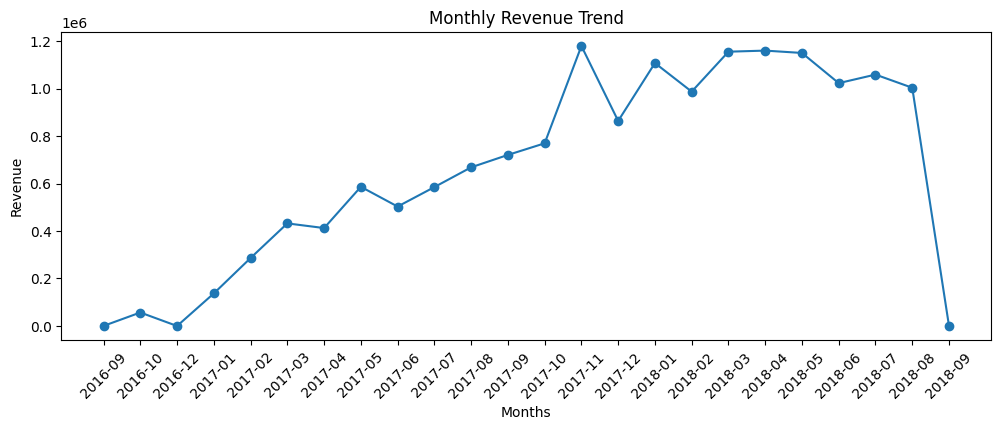

In [35]:
plt.figure(figsize=(12,4))
plt.plot(m1['order_month'].astype(str),m1["monthly_revenue"],marker="o")
plt.xlabel("Months")
plt.ylabel("Revenue")
plt.title("Monthly Revenue Trend")
plt.xticks(rotation=45)
plt.show()

### INSIGHTS :- 
    ~ HIGHEST REVENUE MONTH - NOVEMBER 2017 
    ~ REVENUE - 9,87,766/-
    ~ LOWEST REVENUE MONTH - DECEMBER 2016 
The November peak may indicate seasonal or promotional demand and should be investigated further.

## Monthly Orders trend

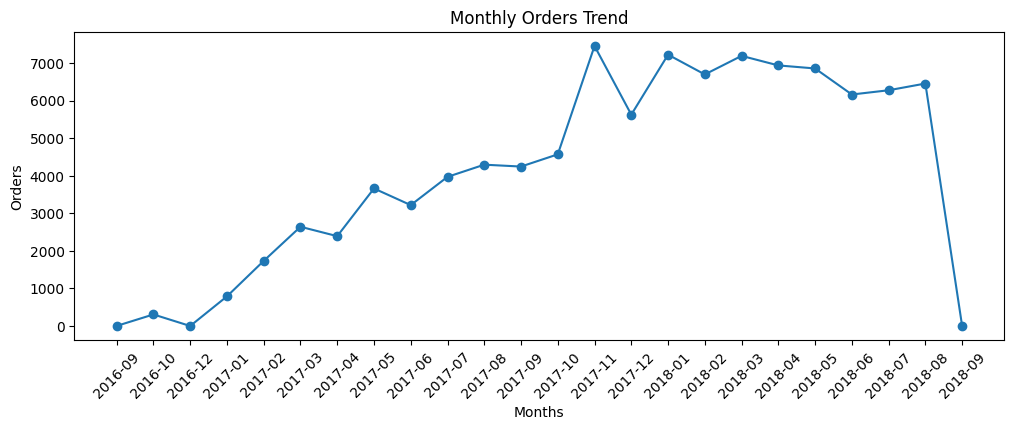

In [36]:
plt.figure(figsize=(12,4))
plt.plot(m1['order_month'].astype(str),m1["monthly_orders"],marker="o")
plt.xlabel("Months")
plt.ylabel("Orders")
plt.title("Monthly Orders Trend")
plt.xticks(rotation=45)
plt.show()

### INSIGHTS :- 
    ~ HIGHEST ORDERS MONTH - NOVEMBER 2017 
    ~ ORDERS - 7451
    ~ LOWEST ORDERS MONTH - DECEMBER 2016 
Monthly order volume generally followed the overall revenue trend, suggesting that changes in revenue were primarily driven 
    by changes in sales volume.

## Monthly AOV trend

In [37]:
m1['monthly_AOV'] = (m1['monthly_revenue']/m1['monthly_orders'])

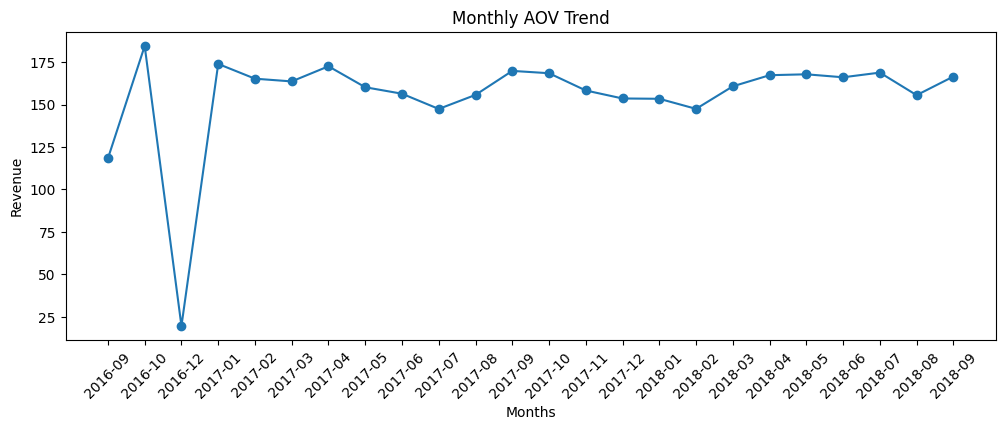

In [38]:
plt.figure(figsize=(12,4))
plt.plot(m1['order_month'].astype(str),m1['monthly_AOV'],marker="o")
plt.xlabel("Months")
plt.ylabel("Revenue")
plt.title("Monthly AOV Trend")
plt.xticks(rotation=45)
plt.show()

### INSIGHTS :- 
    ~ HIGHEST AOV MONTH - APRIL 2017 
    ~ LOWEST AOV MONTH - JULY 2017
The highest AOV occured in April 2017, indicating that customers placed relatively high value orders during this period.
    However, the highest revenue month was November 2017, demonstrating that high revenue can result from either high order
    volume or high order value.

## Analysing the product categories

In [39]:
sales_df.head()

,order_id,order_status,order_purchase_timestamp,product_id,price,freight_value,product_category_name,product_revenue,order_month
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33,87285b34884572647811a353c7ac498a,29.99,8.72,utilidades_domesticas,38.71,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,2018-07-24 20:41:37,595fac2a385ac33a80bd5114aec74eb8,118.70,22.76,perfumaria,141.46,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,2018-08-08 08:38:49,aa4383b373c6aca5d8797843e5594415,159.90,19.22,automotivo,179.12,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,2017-11-18 19:28:06,d0b61bfb1de832b15ba9d266ca96e5b0,45.00,27.20,pet_shop,72.20,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,2018-02-13 21:18:39,65266b2da20d04dbe00c5c2d3bb7859e,19.90,8.72,papelaria,28.62,2018-02


In [40]:
category_analyzer_1 = sales_df.groupby("product_category_name").agg(
    category_based_product_revenue = ('product_revenue',"sum"), 
    category_based_orders_count = ("order_id","nunique"), 
    category_based_items_count = ("product_id","count")
)

In [41]:
category_analyzer_1.sort_values(by="category_based_product_revenue",ascending=False).head(10)

,category_based_product_revenue,category_based_orders_count,category_based_items_count
product_category_name,,,
beleza_saude,1441248.07,8836,9670
relogios_presentes,1305541.61,5624,5991
cama_mesa_banho,1241681.72,9417,11115
esporte_lazer,1156656.48,7720,8641
informatica_acessorios,1059272.40,6689,7827
moveis_decoracao,902511.79,6449,8334
utilidades_domesticas,778397.77,5884,6964
cool_stuff,719329.95,3632,3796
automotivo,685384.32,3897,4235


In [42]:
category_analyzer_1.sort_values(by="category_based_orders_count",ascending=False).head(10)

,category_based_product_revenue,category_based_orders_count,category_based_items_count
product_category_name,,,
cama_mesa_banho,1241681.72,9417,11115
beleza_saude,1441248.07,8836,9670
esporte_lazer,1156656.48,7720,8641
informatica_acessorios,1059272.40,6689,7827
moveis_decoracao,902511.79,6449,8334
utilidades_domesticas,778397.77,5884,6964
relogios_presentes,1305541.61,5624,5991
telefonia,394883.32,4199,4545
automotivo,685384.32,3897,4235


In [43]:
category_analyzer_1.sort_values(by="category_based_items_count",ascending=False).head(10)

,category_based_product_revenue,category_based_orders_count,category_based_items_count
product_category_name,,,
cama_mesa_banho,1241681.72,9417,11115
beleza_saude,1441248.07,8836,9670
esporte_lazer,1156656.48,7720,8641
moveis_decoracao,902511.79,6449,8334
informatica_acessorios,1059272.40,6689,7827
utilidades_domesticas,778397.77,5884,6964
relogios_presentes,1305541.61,5624,5991
telefonia,394883.32,4199,4545
ferramentas_jardim,584219.21,3518,4347


### INSIGHTS :- 
    Category Level Performance Analysis:
    
    #TOP 5 REVENUE CATEGORIES - ["beleza_saude","relogios_presentes","cama_mesa_banho","esporte_lazer","informatica_acessorios"]
    
    #TOP 5 ORDERS CATEGORIES - ["cama_mesa_banho","beleza_saude","esporte_lazer","informatica_acessorios","moveis_decoracao"]
    
    #TOP 5 ITEMS SOLD CATEGORIES - ["cama_mesa_banho","beleza_saude","esporte_lazer","moveis_decoracao","informatica_acessorios"]
Health & Beauty generated the highest category revenue, followed by watches & gifts, bed, table & bath. These categories 
    represent important revenue contributors and should be prioritized for inventory planning and marketing investment. 


In [44]:
category_analyzer_1['revenue_pct'] = ((category_analyzer_1['category_based_product_revenue'])/ category_analyzer_1['category_based_product_revenue'].sum()) * 100

In [45]:
category_analyzer_1['orders_pct'] = ((category_analyzer_1['category_based_orders_count']) / category_analyzer_1['category_based_orders_count'].sum()) * 100

In [46]:
category_analyzer_1.head()

,category_based_product_revenue,category_based_orders_count,category_based_items_count,revenue_pct,orders_pct
product_category_name,,,,,
Unknown,207705.09,1451,1603,1.310975,1.458731
agro_industria_e_comercio,78374.07,182,212,0.494675,0.182970
alimentos,36664.44,450,510,0.231416,0.452398
alimentos_bebidas,19687.47,227,278,0.124262,0.228210
artes,28247.81,202,209,0.178292,0.203076


In [47]:
revenue_pct_median = category_analyzer_1['revenue_pct'].median() 
orders_pct_median = category_analyzer_1['orders_pct'].median()

In [48]:
category_analyzer_1['High_revenue'] = category_analyzer_1['revenue_pct'] >= revenue_pct_median
category_analyzer_1['Low_revenue'] = category_analyzer_1['revenue_pct'] < revenue_pct_median
category_analyzer_1['High_orders'] = category_analyzer_1['orders_pct'] >= orders_pct_median
category_analyzer_1['Low_orders'] = category_analyzer_1['orders_pct'] < orders_pct_median

In [49]:
category_analyzer_1.head()

,category_based_product_revenue,category_based_orders_count,category_based_items_count,revenue_pct,orders_pct,High_revenue,Low_revenue,High_orders,Low_orders
product_category_name,,,,,,,,,
Unknown,207705.09,1451,1603,1.310975,1.458731,True,False,True,False
agro_industria_e_comercio,78374.07,182,212,0.494675,0.182970,True,False,False,True
alimentos,36664.44,450,510,0.231416,0.452398,False,True,True,False
alimentos_bebidas,19687.47,227,278,0.124262,0.228210,False,True,False,True
artes,28247.81,202,209,0.178292,0.203076,False,True,False,True


In [50]:
high_revenue_high_order = category_analyzer_1[(category_analyzer_1['High_revenue']==True) & (category_analyzer_1['High_orders']==True)] 
high_revenue_low_order = category_analyzer_1[(category_analyzer_1['High_revenue']==True) & (category_analyzer_1['High_orders']==False)] 
low_revenue_high_order = category_analyzer_1[(category_analyzer_1['High_revenue']==False) & (category_analyzer_1['High_orders']==True)] 
low_revenue_low_order = category_analyzer_1[(category_analyzer_1['High_revenue']==False) & (category_analyzer_1['High_orders']==False)] 

In [51]:
category_analyzer_1.drop(columns=['Low_revenue','Low_orders'],inplace=True)

In [52]:
category_analyzer_1.head()

,category_based_product_revenue,category_based_orders_count,category_based_items_count,revenue_pct,orders_pct,High_revenue,High_orders
product_category_name,,,,,,,
Unknown,207705.09,1451,1603,1.310975,1.458731,True,True
agro_industria_e_comercio,78374.07,182,212,0.494675,0.182970,True,False
alimentos,36664.44,450,510,0.231416,0.452398,False,True
alimentos_bebidas,19687.47,227,278,0.124262,0.228210,False,False
artes,28247.81,202,209,0.178292,0.203076,False,False


In [53]:
high_revenue_high_order.head()

,category_based_product_revenue,category_based_orders_count,category_based_items_count,revenue_pct,orders_pct,High_revenue,Low_revenue,High_orders,Low_orders
product_category_name,,,,,,,,,
Unknown,207705.09,1451,1603,1.310975,1.458731,True,False,True,False
audio,56398.94,350,364,0.355974,0.351865,True,False,True,False
automotivo,685384.32,3897,4235,4.325951,3.917764,True,False,True,False
bebes,480118.00,2885,3065,3.030368,2.900372,True,False,True,False
beleza_saude,1441248.07,8836,9670,9.096748,8.883080,True,False,True,False


In [54]:
low_revenue_low_order.head()

,category_based_product_revenue,category_based_orders_count,category_based_items_count,revenue_pct,orders_pct,High_revenue,Low_revenue,High_orders,Low_orders
product_category_name,,,,,,,,,
alimentos_bebidas,19687.47,227,278,0.124262,0.228210,False,True,False,True
artes,28247.81,202,209,0.178292,0.203076,False,True,False,True
artes_e_artesanato,2184.14,23,24,0.013786,0.023123,False,True,False,True
artigos_de_festas,5313.15,39,43,0.033535,0.039208,False,True,False,True
artigos_de_natal,12030.12,128,153,0.075931,0.128682,False,True,False,True


In [56]:
high_revenue_low_order.index

Index(['agro_industria_e_comercio', 'eletrodomesticos_2', 'pcs',
       'telefonia_fixa'],
      dtype='object', name='product_category_name')

In [57]:
low_revenue_high_order.index

Index(['alimentos', 'bebidas', 'livros_tecnicos', 'market_place'], dtype='object', name='product_category_name')

In [59]:
product_level_performance = (sales_df.groupby(['product_id','product_category_name']).agg(
    total_revenues = ("product_revenue","sum"), 
    units_sold = ("product_id","size")
).reset_index())

In [62]:
top_10_products_by_revenue = product_level_performance.sort_values('total_revenues',ascending=False).head(10)

In [63]:
top_10_products_by_units_sold = product_level_performance.sort_values('units_sold',ascending=False).head(10)

In [64]:
top_10_products_by_revenue

,product_id,product_category_name,total_revenues,units_sold
24086,bb50f2e236e5eea0100680137654686c,beleza_saude,67606.10,195
27039,d1c427060a0f73f6b889a5c7c61f2ac4,informatica_acessorios,60976.03,343
14068,6cdd53843498f92890544667809f1595,beleza_saude,59093.99,156
19742,99a4788cb24856965c36a24e339b6058,cama_mesa_banho,51071.60,488
27613,d6160fb7873f184099d9bc95e30376af,pcs,50326.18,35
8051,3dd2a17168ec895c781a9191c1e95ad7,informatica_acessorios,48212.22,274
22112,aca2eb7d00ea1a7b8ebd4e68314663af,moveis_decoracao,44820.76,527
12351,5f504b3a1c75b73d6151be81eb05bdc9,cool_stuff,41725.81,63
4996,25c38557cf793876c5abdd5931f922db,bebes,40311.95,38
10867,53b36df67ebb7c41585e8d54d6772e08,relogios_presentes,39957.93,323


In [65]:
top_10_products_by_units_sold

,product_id,product_category_name,total_revenues,units_sold
22112,aca2eb7d00ea1a7b8ebd4e68314663af,moveis_decoracao,44820.76,527
19742,99a4788cb24856965c36a24e339b6058,cama_mesa_banho,51071.60,488
8613,422879e10f46682990de24d770e7f83d,ferramentas_jardim,34201.26,484
7364,389d119b48cf3043d311335e499d9c6b,ferramentas_jardim,28682.68,392
7079,368c6c730842d78016ad823897a372db,ferramentas_jardim,27984.40,388
10840,53759a2ecddad2bb87a079a1f1519f73,ferramentas_jardim,27268.23,373
27039,d1c427060a0f73f6b889a5c7c61f2ac4,informatica_acessorios,60976.03,343
10867,53b36df67ebb7c41585e8d54d6772e08,relogios_presentes,39957.93,323
2794,154e7e31ebfa092203795c972e5804a6,beleza_saude,10063.11,281
8051,3dd2a17168ec895c781a9191c1e95ad7,informatica_acessorios,48212.22,274


In [66]:
product_level_performance['average_price'] = product_level_performance['total_revenues'] / product_level_performance['units_sold']

In [67]:
product_level_performance.head()

,product_id,product_category_name,total_revenues,units_sold,average_price
0,00066f42aeeb9f3007548bb9d3f33c38,perfumaria,120.24,1,120.24
1,00088930e925c41fd95ebfe695fd2655,automotivo,143.83,1,143.83
2,0009406fd7479715e4bef61dd91f2462,cama_mesa_banho,242.10,1,242.10
3,000b8f95fcb9e0096488278317764d19,utilidades_domesticas,157.00,2,78.50
4,000d9be29b5207b54e86aa1b1ac54872,relogios_presentes,218.27,1,218.27


In [68]:
top_10_products_by_average_price = product_level_performance.sort_values('average_price',ascending=False).head(10)

In [69]:
top_10_products_by_average_price

,product_id,product_category_name,total_revenues,units_sold,average_price
9434,489ae2aa008f021502940f251d4cce7f,utilidades_domesticas,6929.31,1,6929.31
13693,69c590f7ffc7bf8db97190b6cb6ed62e,pcs,6922.21,1,6922.21
3698,1bdf5e6731585cf01aa8169c7028d6ad,artes,6726.66,1,6726.66
21316,a6492cc69376c469ab6f61d8f44de961,eletroportateis,4950.34,1,4950.34
25197,c3ed642d592594bb648ff4a04cee2747,eletroportateis,4764.34,1,4764.34
4967,259037a6a41845e455183f89c5035f18,pcs,4681.78,1,4681.78
20782,a1beef8f3992dbd4cd8726796aa69c53,instrumentos_musicais,4513.32,1,4513.32
9968,4ca7b91a31637bd24fb8e559d5e015e4,eletroportateis,4194.76,1,4194.76
14070,6cdf8fc1d741c76586d8b6b15e9eef30,consoles_games,4175.26,1,4175.26
9913,4c50dcc50f1512f46096d6ef0142c4a9,Unknown,4042.74,1,4042.74


In [74]:
product_level_performance['average_price'].median()

np.float64(96.63000000000001)

In [76]:
product_level_performance['units_sold'].describe()

count    32951.000000
mean         3.418713
std         10.619709
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max        527.000000
Name: units_sold, dtype: float64

In [79]:
product_level_performance.head()

,product_id,product_category_name,total_revenues,units_sold,average_price,performance_type
0,00066f42aeeb9f3007548bb9d3f33c38,perfumaria,120.24,1,120.24,other
1,00088930e925c41fd95ebfe695fd2655,automotivo,143.83,1,143.83,other
2,0009406fd7479715e4bef61dd91f2462,cama_mesa_banho,242.10,1,242.10,other
3,000b8f95fcb9e0096488278317764d19,utilidades_domesticas,157.00,2,78.50,other
4,000d9be29b5207b54e86aa1b1ac54872,relogios_presentes,218.27,1,218.27,other


In [81]:
product_level_performance['performance_segment'] = 'Low volume - Low Price'

In [82]:
product_level_performance.loc[
     (product_level_performance['units_sold'] > 3) & (product_level_performance['average_price']>= 96), 
    'performance_segment'] = 'High_volume - High Price'

In [83]:
product_level_performance.loc[
     (product_level_performance['units_sold'] > 3) & (product_level_performance['average_price'] < 96), 
    'performance_segment'] = "High volume - Low price"

In [84]:
product_level_performance.loc[
     (product_level_performance['units_sold'] <= 3) & (product_level_performance['average_price']>= 96), 
    'performance_segment'] = "Low volume - High price"

In [86]:
product_level_performance.drop(columns='performance_type',inplace=True)

In [87]:
product_level_performance.head(10)

,product_id,product_category_name,total_revenues,units_sold,average_price,performance_segment
0,00066f42aeeb9f3007548bb9d3f33c38,perfumaria,120.24,1,120.240000,Low volume - High price
1,00088930e925c41fd95ebfe695fd2655,automotivo,143.83,1,143.830000,Low volume - High price
2,0009406fd7479715e4bef61dd91f2462,cama_mesa_banho,242.10,1,242.100000,Low volume - High price
3,000b8f95fcb9e0096488278317764d19,utilidades_domesticas,157.00,2,78.500000,Low volume - Low Price
4,000d9be29b5207b54e86aa1b1ac54872,relogios_presentes,218.27,1,218.270000,Low volume - High price
5,0011c512eb256aa0dbbb544d8dffcf6e,automotivo,67.80,1,67.800000,Low volume - Low Price
6,00126f27c813603687e6ce486d909d01,cool_stuff,527.73,2,263.865000,Low volume - High price
7,001795ec6f1b187d37335e1c4704762e,consoles_games,456.20,9,50.688889,High volume - Low price
8,001b237c0e9bb435f2e54071129237e9,cama_mesa_banho,100.09,1,100.090000,Low volume - High price
9,001b72dfd63e9833e8c02742adf472e3,moveis_decoracao,664.54,14,47.467143,High volume - Low price


In [88]:
product_level_performance['performance_segment'].value_counts()

performance_segment
Low volume - High price     13673
Low volume - Low Price      12912
High volume - Low price      3469
High_volume - High Price     2897
Name: count, dtype: int64

In [98]:
top_10_products_by_revenue['average_price'] = top_10_products_by_revenue['total_revenues'] / top_10_products_by_revenue['units_sold']

In [99]:
top_10_products_by_revenue

,product_id,product_category_name,total_revenues,units_sold,average_price
24086,bb50f2e236e5eea0100680137654686c,beleza_saude,67606.10,195,346.697949
27039,d1c427060a0f73f6b889a5c7c61f2ac4,informatica_acessorios,60976.03,343,177.772682
14068,6cdd53843498f92890544667809f1595,beleza_saude,59093.99,156,378.807628
19742,99a4788cb24856965c36a24e339b6058,cama_mesa_banho,51071.60,488,104.654918
27613,d6160fb7873f184099d9bc95e30376af,pcs,50326.18,35,1437.890857
8051,3dd2a17168ec895c781a9191c1e95ad7,informatica_acessorios,48212.22,274,175.957007
22112,aca2eb7d00ea1a7b8ebd4e68314663af,moveis_decoracao,44820.76,527,85.048880
12351,5f504b3a1c75b73d6151be81eb05bdc9,cool_stuff,41725.81,63,662.314444
4996,25c38557cf793876c5abdd5931f922db,bebes,40311.95,38,1060.840789
10867,53b36df67ebb7c41585e8d54d6772e08,relogios_presentes,39957.93,323,123.708762


### INSIGHTS :- 
    Product level Performance analysis: 
        # HIGHEST REVENUE PRODUCT - INDEX(24086) : 67606.10	
        # HIGHEST ORDERS PRODUCT - INDEX(22112) : 527
        # performance_segment :-
           ~ Low volume - High price  : 13673
           ~ Low volume - Low Price   : 12912
           ~ High volume - Low price  : 3469
           ~ High_volume - High Price : 2897 
    Products with the highest average price often had only one unit sold. Therefore, high average price alone should
        not be considered a measrue of product success. 
        # Product Demand Distribution :- 
           ~ median units sold - 1
           ~ mean units sold - 3.4 
           ~ maximum - 527
           ~ 75th percentile - 3
product demand is highly right skewed. The median product sold only by 1 unt, while a small number of products
           achieved extremely high sales volumes, with top product reaching 527 units. This indicates that product demand is 
           concentrated among a relatively small number of high performing products.

## Freight Performance analysing

In [100]:
sales_df.head()

,order_id,order_status,order_purchase_timestamp,product_id,price,freight_value,product_category_name,product_revenue,order_month
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33,87285b34884572647811a353c7ac498a,29.99,8.72,utilidades_domesticas,38.71,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,2018-07-24 20:41:37,595fac2a385ac33a80bd5114aec74eb8,118.70,22.76,perfumaria,141.46,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,2018-08-08 08:38:49,aa4383b373c6aca5d8797843e5594415,159.90,19.22,automotivo,179.12,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,2017-11-18 19:28:06,d0b61bfb1de832b15ba9d266ca96e5b0,45.00,27.20,pet_shop,72.20,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,2018-02-13 21:18:39,65266b2da20d04dbe00c5c2d3bb7859e,19.90,8.72,papelaria,28.62,2018-02


In [104]:
sales_df['freight_percentage'] = (sales_df['freight_value'] / sales_df['product_revenue']) * 100

In [106]:
sales_df.drop(columns='freight_perentage',inplace=True)

In [107]:
sales_df[['freight_percentage','freight_value','product_revenue']].describe()

,freight_percentage,freight_value,product_revenue
count,112650.000000,112650.000000,112650.000000
mean,21.336434,19.990320,140.644059
std,12.949813,15.806405,190.724394
min,0.000000,0.000000,6.080000
25%,11.819196,13.080000,55.220000
50%,18.788733,16.260000,92.320000
75%,28.214357,21.150000,157.937500
max,96.328294,409.680000,6929.310000


### INSIGHTS :- 
    ~ AVERAGE FREIGHT PERCENTAGE - 21.33 
    ~ MEDIAN FREIGHT PERCENTAGE - 18.78 
    ~ MAXIMUM FREIGHT PERCENTAGE - 96.32 
The maximum freight percentage of approximately 96% indicates that some orders have extremely high
    shipping costs relative to product value. 

In [129]:
category_freight_analysis = (sales_df.groupby("product_category_name").agg(
    total_freight = ('freight_value','sum'), 
    total_revenue = ('product_revenue','sum')
).reset_index())

In [130]:
category_freight_analysis['freight_percentage'] = (category_freight_analysis['total_freight'] / category_freight_analysis['total_revenue'])*100

In [132]:
top_10_category_by_freight_cost = category_freight_analysis.sort_values(by='total_freight',ascending=False).head(10)

In [133]:
top_10_category_by_freight_pct = category_freight_analysis.sort_values(by='freight_percentage',ascending=False).head(10)

In [134]:
top_10_category_by_freight_cost

,product_category_name,total_freight,total_revenue,freight_percentage
14,cama_mesa_banho,204693.04,1241681.72,16.485146
12,beleza_saude,182566.73,1441248.07,12.667266
55,moveis_decoracao,172749.30,902511.79,19.140947
33,esporte_lazer,168607.51,1156656.48,14.577147
45,informatica_acessorios,147318.08,1059272.40,13.907478
73,utilidades_domesticas,146149.11,778397.77,18.775633
67,relogios_presentes,100535.93,1305541.61,7.700707
41,ferramentas_jardim,98962.75,584219.21,16.939318
9,automotivo,92664.21,685384.32,13.520036
27,cool_stuff,84039.10,719329.95,11.682970


In [135]:
top_10_category_by_freight_pct

,product_category_name,total_freight,total_revenue,freight_percentage
16,casa_conforto_2,410.31,1170.58,35.051855
42,flores,488.87,1598.91,30.575204
53,moveis_colchao_e_estofado,1630.46,5998.54,27.180947
7,artigos_de_natal,3229.30,12030.12,26.843456
43,fraldas_higiene,573.68,2141.27,26.791577
18,cds_dvds_musicais,224.99,954.99,23.559409
69,sinalizacao_e_seguranca,6507.82,28017.05,23.228070
3,alimentos_bebidas,4507.99,19687.47,22.897762
31,eletronicos,46578.32,206825.06,22.520637
36,fashion_esporte,578.13,2697.64,21.430954


### INSIGHTS :- 
    ~ High Freight % categories - [casa_conforto_2, flores, moveis_colchao_e_estofado, artigos_de_natal, fraldas_higiene] 
    ~ High Freight Cost categories - [cama_mesa_banho, beleza_saude, moveis_decoracao, esporte_lazer, informatica_acessorios] 
Freight burden varies considerably across product categories. Categories involving bulky, heavy or low value products
    can have disproportionately high logistics costs. 
### BUSINESS RECOMMENDATION :- 
The company should investigate high freight to revenue categories for shipping optimiztion, supplier location strategies,
    minimum order thresholds, or alternative logistics partnerships.

In [136]:
sales_df['order_value_band'] = pd.qcut(
    sales_df['product_revenue'],q=4,
    labels=['low value','medium-low value','medium-high value','high value']
)

In [137]:
sales_df.head()

,order_id,order_status,order_purchase_timestamp,product_id,price,freight_value,product_category_name,product_revenue,order_month,freight_percentage,order_value_band
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33,87285b34884572647811a353c7ac498a,29.99,8.72,utilidades_domesticas,38.71,2017-10,22.526479,low value
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,2018-07-24 20:41:37,595fac2a385ac33a80bd5114aec74eb8,118.70,22.76,perfumaria,141.46,2018-07,16.089354,medium-high value
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,2018-08-08 08:38:49,aa4383b373c6aca5d8797843e5594415,159.90,19.22,automotivo,179.12,2018-08,10.730237,high value
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,2017-11-18 19:28:06,d0b61bfb1de832b15ba9d266ca96e5b0,45.00,27.20,pet_shop,72.20,2017-11,37.673130,medium-low value
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,2018-02-13 21:18:39,65266b2da20d04dbe00c5c2d3bb7859e,19.90,8.72,papelaria,28.62,2018-02,30.468204,low value


In [140]:
order_value_freight_analysis = (sales_df.groupby('order_value_band',observed=True).agg(
    avg_product_revenue = ("product_revenue","mean"), 
    total_revenue = ("product_revenue","sum"), 
    total_freight = ("freight_value","sum"), 
    avg_freight_percentage = ("freight_percentage","mean"), 
    order_count = ("order_id","nunique")
).reset_index())

In [141]:
order_value_freight_analysis["freight_percentage_overall"] = (
    order_value_freight_analysis['total_freight'] / order_value_freight_analysis['total_revenue']
) * 100

In [142]:
order_value_freight_analysis.head()

,order_value_band,avg_product_revenue,total_revenue,total_freight,avg_freight_percentage,order_count,freight_percentage_overall
0,low value,39.214962,1104450.20,370991.73,34.920236,23545,33.590625
1,medium-low value,72.420512,2039940.97,457842.67,22.707959,24698,22.443918
2,medium-high value,121.124173,3410251.10,550811.67,16.308971,25562,16.151646
3,high value,329.826757,9288910.97,872263.47,11.406418,26232,9.390374


### INSIGHTS :- 
FREIGHT VS ORDER VALUE :- 
    ~ LOW VALUE - 33.60
    ~ MEDIUM LOW VALUE - 22.45
    ~ MEDIUM HIGH VALUE - 16.15
    ~ HIGH VALUE - 9.40
Freight burden decreases as order value increases. Low value orders have an aversge freight percentage of approximately 
34% compared with approximately 9.5% for high order value. 
### BUSINESS IMPLICATION :- 
Low value orders are significantly less economically efficient because shipping costs consume a larger proportion
of the order value.
### RECOMMENDATION :- 
The company could improve profitability by encouraging customers to increase basket size through shipping thresholds, 
product bundles, cross - selling, or minimun values for free delivery.

## FINAL SALES & REVENUE INSIGHTS :- 

## 1. Overall Sales Performance
The analysis provides an overview of the business's sales and revenue performance across the available Olist transaction period, highlighting overall revenue generation and order activity.

## 2. Monthly Revenue Performance
Revenue performance varies across months, indicating changes in sales demand over time. November 2017 recorded the highest monthly revenue in the analysis, with approximately 987.8K in revenue.

## 3. Product and Category Performance
Revenue contribution is not evenly distributed across product categories. Certain categories contribute significantly more to overall revenue, highlighting the importance of focusing on high-performing categories while evaluating weaker categories for improvement.

## 4. Revenue and Order Volume
Changes in revenue and order volume provide insight into the relationship between transaction activity and business performance. Monitoring both metrics together helps distinguish periods of high demand from periods where order volume and revenue behave differently.

## 5. Freight Contribution
Freight represents a significant component of the overall sales economics. Comparing freight with revenue across product categories can help identify categories where logistics costs may have a greater impact on overall business performance.

## 6. Business Opportunity
The analysis suggests that the business should prioritize high-performing product categories, investigate periods of strong demand, and monitor freight costs alongside revenue to support better sales and operational decisions.